# Ljungqvist & Sargent, *Recursive Macroeconomic Theory* (4th ed., 2018) — Chapter 2, Time Series

Companion notebook to `ls_solutions_ch02.tex`. One section per exercise (2.1–2.30). Every numerical
answer is computed one way and then re-derived by an independent route (closed form vs. recursion,
truncated sum, simulation, Riccati solver, or brute-force Gaussian conditioning), with an `assert`
that aborts on mismatch. Figures used in the PDF are written to `fig/ls02_*.pdf` through the `pgf`
backend (lmodern + cmap, Type 1 fonts only).

Notation follows the book: state $x_{t+1}=Ax_t+Cw_{t+1}$, observation $y_t=Gx_t(+v_t)$, Kalman
recursions (2.7.14), discrete Lyapunov equation (2.4.10), Howard iterations (2.4.30).

In [1]:
import numpy as np
import scipy.linalg as la
from scipy import signal, integrate
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

np.set_printoptions(precision=6, suppress=True)
FIG = Path("fig"); FIG.mkdir(exist_ok=True)
rng = np.random.default_rng(20180503)

PGF = {"pgf.texsystem": "pdflatex", "pgf.rcfonts": False, "font.family": "serif",
       "font.size": 9, "axes.titlesize": 9, "legend.fontsize": 7.5,
       "pgf.preamble": "\n".join([r"\usepackage[T1]{fontenc}", r"\usepackage{lmodern}",
                                  r"\usepackage{cmap}", r"\usepackage{amsmath}"])}

def save_pdf(fig, name):
    """Write fig to fig/ls02_<name>.pdf via pgf (text typeset by pdflatex -> Type 1 fonts)."""
    with mpl.rc_context(PGF):
        fig.savefig(FIG / f"ls02_{name}.pdf", backend="pgf", bbox_inches="tight")

def doublej(A, CC, tol=1e-14, maxit=200):
    """Doubling algorithm for X = A X A' + CC (works with a unit root attached to a constant
    as long as CC loads nothing on it, like the book's doublej.m)."""
    a, g = A.copy(), CC.copy()
    for _ in range(maxit):
        g_new = g + a @ g @ a.T
        a = a @ a
        if np.max(np.abs(g_new - g)) < tol * max(1.0, np.max(np.abs(g_new))):
            return g_new
        g = g_new
    raise RuntimeError("doublej did not converge")

def kalman_steady(A, C, G, R, S0=None, tol=1e-13, maxit=100000):
    """Iterate (2.7.14b,d) to the fixed point; returns K, Sigma."""
    n = A.shape[0]
    S = np.eye(n) if S0 is None else S0
    for _ in range(maxit):
        K = A @ S @ G.T @ np.linalg.inv(G @ S @ G.T + R)
        Sn = C @ C.T + K @ R @ K.T + (A - K @ G) @ S @ (A - K @ G).T
        if np.max(np.abs(Sn - S)) < tol:
            return K, Sn
        S = Sn
    raise RuntimeError("Riccati iteration did not converge")

## Exercise 2.1 — likelihood of three histories

$P=\begin{bmatrix}.9&.1\\.3&.7\end{bmatrix}$, $\pi_0=[.5,.5]'$, $\bar y=[1,5]'$.
The likelihood of a history is $\pi_{0,i_0}\prod_{t=1}^{4}P_{i_{t-1}i_t}$.
Cross-check: the forward recursion $\alpha_t'=(\alpha_{t-1}'P)\odot \mathbf 1\{y_t\}$.

In [2]:
P1 = np.array([[.9, .1], [.3, .7]]); pi0 = np.array([.5, .5]); ybar = np.array([1, 5])
def lik_product(P, pi0, idx):
    L = pi0[idx[0]]
    for a, b in zip(idx[:-1], idx[1:]):
        L *= P[a, b]
    return L
def lik_forward(P, pi0, ys, ybar):
    alpha = pi0 * (ybar == ys[0])
    for y in ys[1:]:
        alpha = (alpha @ P) * (ybar == y)
    return alpha.sum()
hist = {"a": [1, 5, 1, 5, 1], "b": [1, 1, 1, 1, 1], "c": [5, 5, 5, 5, 5]}
for k, h in hist.items():
    idx = [list(ybar).index(y) for y in h]
    L1, L2 = lik_product(P1, pi0, idx), lik_forward(P1, pi0, h, ybar)
    assert np.isclose(L1, L2)
    print(k, h, f"likelihood = {L1:.6f}")
assert np.isclose(lik_product(P1, pi0, [0, 1, 0, 1, 0]), .5 * .1 * .3 * .1 * .3)

a [1, 5, 1, 5, 1] likelihood = 0.000450
b [1, 1, 1, 1, 1] likelihood = 0.328050
c [5, 5, 5, 5, 5] likelihood = 0.120050


## Exercise 2.2 — recovering $P$ from conditional moments

$P\bar y=[1.8,3.4]'$, $P\bar y^2=[5.8,15.4]'$ with $\bar y=[1,5]'$, rows summing to one.
Stack the 6 linear equations in the 4 unknowns $\mathrm{vec}(P)$; uniqueness $\Leftrightarrow$ full column rank.

In [3]:
y = np.array([1., 5.])
M, rhs = [], []
for i, (m1, m2) in enumerate([(1.8, 5.8), (3.4, 15.4)]):
    for vec, r in [(np.ones(2), 1.), (y, m1), (y**2, m2)]:
        row = np.zeros(4); row[2*i:2*i+2] = vec; M.append(row); rhs.append(r)
M, rhs = np.array(M), np.array(rhs)
sol, res, rank, _ = np.linalg.lstsq(M, rhs, rcond=None)
P2 = sol.reshape(2, 2)
print("P =\n", P2, "\nrank of stacked system:", rank, " residual:", res)
assert rank == 4 and np.allclose(M @ sol, rhs)
# the first moment alone already pins P (rank 4 without the second-moment rows)
assert np.linalg.matrix_rank(M[[0, 1, 3, 4]]) == 4
assert np.allclose(P2, [[.8, .2], [.4, .6]])

P =
 [[0.8 0.2]
 [0.4 0.6]] 
rank of stacked system: 4  residual: [0.]


## Exercise 2.3 — discounted utility and Bayesian model choice

$v=(I-\beta P)^{-1}u$, $V=\pi_0'v$. Cross-check with the truncated sum $\sum_{t\le 3000}\beta^tP^tu$.

In [4]:
def crra(c, g): return c**(1 - g) / (1 - g)
beta = .95; cbar = np.array([1., 5.]); pi0 = np.array([.5, .5])
procs = {1: np.eye(2), 2: np.full((2, 2), .5)}
for g in (2.5, 4.0):
    u = crra(cbar, g)
    for k, P in procs.items():
        v = np.linalg.solve(np.eye(2) - beta * P, u)
        v_sum, Pt = np.zeros(2), np.eye(2)
        for t in range(3000):
            v_sum += beta**t * Pt @ u; Pt = Pt @ P
        assert np.allclose(v, v_sum)
        print(f"gamma={g}, process {k}: v={v}, V={pi0 @ v:.6f}")
    V1 = pi0 @ np.linalg.solve(np.eye(2) - beta * procs[1], u)
    V2 = pi0 @ np.linalg.solve(np.eye(2) - beta * procs[2], u)
    assert np.isclose(V1, V2) and np.isclose(V1, (pi0 @ u) / (1 - beta))

# parts c-e: likelihoods and posteriors
data_c = [1] * 10
data_e = [1, 5, 5, 1, 5, 5, 1, 5, 1, 5]
for name, d in [("c/d", data_c), ("e", data_e)]:
    L = np.array([lik_forward(procs[k], pi0, d, cbar) for k in (1, 2)])
    post = L * .5 / (L * .5).sum()
    print(name, "likelihoods:", L, " posterior:", post)
Lc = np.array([lik_forward(procs[k], pi0, data_c, cbar) for k in (1, 2)])
assert np.allclose(Lc, [.5, .5**10])
assert np.isclose(Lc[0] / Lc.sum(), 512 / 513)

gamma=2.5, process 1: v=[-13.333333  -1.19257 ], V=-7.262951
gamma=2.5, process 2: v=[-7.566471 -6.959432], V=-7.262951
gamma=4.0, process 1: v=[-6.666667 -0.053333], V=-3.360000
gamma=4.0, process 2: v=[-3.525333 -3.194667], V=-3.360000
c/d likelihoods: [0.5      0.000977]  posterior: [0.998051 0.001949]
e likelihoods: [0.       0.000977]  posterior: [0. 1.]


## Exercise 2.4 — AR(4) with a constant as a first-order system

$x_t=[y_t,y_{t-1},y_{t-2},y_{t-3},1]'$, $x_{t+1}=Ax_t+Cw_{t+1}$, $C=[c,0,0,0,0]'$, $G=[1,0,0,0,0]$.
Stationary mean: unit eigenvector of $A$ scaled so that the last entry is 1. Stationary covariance:
$\Sigma_\infty=A\Sigma_\infty A'+CC'$ (doubling). Cross-check: $\mathrm{Var}(y)=\sum_j (GA^jC)^2$,
autocovariance $\sum_j (GA^jC)(GA^{j+k}C)$, and the AR(2)/AR(1) closed forms.
$E_ty_{t+5}=GA^5x_t$; $E_t\sum_k .95^ky_{t+k}=G(I-.95A)^{-1}x_t$.

In [5]:
def ar4(rho, mu, c):
    A = np.zeros((5, 5)); A[0, :4] = rho; A[0, 4] = mu * (1 - sum(rho))
    A[1, 0] = A[2, 1] = A[3, 2] = 1; A[4, 4] = 1
    C = np.zeros((5, 1)); C[0, 0] = c
    return A, C
cases = {"i": ([1.2, -.3, 0, 0], 10, 1), "ii": ([1.2, -.3, 0, 0], 10, 2),
         "iii": ([.9, 0, 0, 0], 5, 1), "iv": ([.2, 0, 0, .5], 5, 1), "v": ([.8, .3, 0, 0], 5, 1)}
G4 = np.array([[1., 0, 0, 0, 0]])
res24 = {}
for key, (rho, mu, c) in cases.items():
    A, C = ar4(rho, mu, c)
    lam = np.linalg.eigvals(A[:4, :4]); rad = max(abs(lam))
    A5 = np.linalg.matrix_power(A, 5)
    out = {"eig": np.sort_complex(lam), "rad": rad, "h5": A5[0, :4], "g0": A5[0, 4]}
    if rad < 1:
        w, V = np.linalg.eig(A); j = np.argmin(abs(w - 1)); mean = np.real(V[:, j] / V[4, j])
        S = doublej(A, C @ C.T)
        H = (G4 @ np.linalg.inv(np.eye(5) - .95 * A)).ravel()
        acov = {k: (G4 @ np.linalg.matrix_power(A, k) @ S @ G4.T).item() for k in (1, 5, 10)}
        # independent route: impulse responses
        psi = np.array([(G4 @ np.linalg.matrix_power(A, j) @ C).item() for j in range(3000)])
        assert np.isclose(S[0, 0], psi @ psi)
        for k in (1, 5, 10):
            assert np.isclose(acov[k], psi[:-k] @ psi[k:])
        Hsum = sum(.95**k * np.linalg.matrix_power(A, k)[0] for k in range(1500))
        assert np.allclose(H, Hsum)
        assert np.isclose(mean[0], mu)
        out.update(mean=mean[0], var=S[0, 0], htil=H[:4], htil_const=H[4], acov=acov)
    res24[key] = out
    print(key, {k: (np.round(v, 5) if isinstance(v, np.ndarray) else v) for k, v in out.items()})
def ar2_var(r1, r2, s2): return (1 - r2) * s2 / ((1 + r2) * ((1 - r2)**2 - r1**2))
assert np.isclose(res24["i"]["var"], ar2_var(1.2, -.3, 1))
assert np.isclose(res24["ii"]["var"], ar2_var(1.2, -.3, 4))
assert np.isclose(res24["iii"]["var"], 1 / (1 - .81))
print("case v: .95 * spectral radius =", .95 * res24["v"]["rad"], "(> 1: the discounted sum diverges)")

i {'eig': array([0.     +0.j, 0.     +0.j, 0.35505+0.j, 0.84495+0.j]), 'rad': np.float64(0.8449489742783177), 'h5': array([ 0.73872, -0.26028,  0.     ,  0.     ]), 'g0': np.float64(5.215600000000006), 'mean': np.float64(10.000000000000005), 'var': np.float64(7.428571428571427), 'htil': array([ 7.64818, -2.17973,  0.     ,  0.     ]), 'htil_const': np.float64(145.31548757170157), 'acov': {1: 6.857142857142856, 5: 3.702857142857141, 10: 1.5975791999999995}}
ii {'eig': array([0.     +0.j, 0.     +0.j, 0.35505+0.j, 0.84495+0.j]), 'rad': np.float64(0.8449489742783177), 'h5': array([ 0.73872, -0.26028,  0.     ,  0.     ]), 'g0': np.float64(5.215600000000006), 'mean': np.float64(10.000000000000005), 'var': np.float64(29.714285714285708), 'htil': array([ 7.64818, -2.17973,  0.     ,  0.     ]), 'htil_const': np.float64(145.31548757170157), 'acov': {1: 27.428571428571423, 5: 14.811428571428564, 10: 6.390316799999998}}


iii {'eig': array([0. +0.j, 0. +0.j, 0. +0.j, 0.9+0.j]), 'rad': np.float64(0.9), 'h5': array([0.59049, 0.     , 0.     , 0.     ]), 'g0': np.float64(2.0475499999999998), 'mean': np.float64(5.0), 'var': np.float64(5.263157894736844), 'htil': array([6.89655, 0.     , 0.     , 0.     ]), 'htil_const': np.float64(65.51724137931026), 'acov': {1: 4.73684210526316, 5: 3.10784210526316, 10: 1.8351496847368436}}
iv {'eig': array([-0.79502+0.j     ,  0.04965-0.83646j,  0.04965+0.83646j,
        0.89573+0.j     ]), 'rad': np.float64(0.8957289964623478), 'h5': array([0.20032, 0.02   , 0.004  , 0.2508 ]), 'g0': np.float64(2.6244000000000005), 'mean': np.float64(5.000000000000032), 'var': np.float64(1.4763984196298612), 'htil': array([2.48295, 1.06441, 1.12043, 1.1794 ]), 'htil_const': np.float64(70.7640500003879), 'acov': {1: 0.415886878768975, 5: 0.36523185693491383, 10: 0.1315787165730922}}
v {'eig': array([-0.27823+0.j,  0.     +0.j,  0.     +0.j,  1.07823+0.j]), 'rad': np.float64(1.078232998312

## Exercise 2.5 — value of a consumption process with quadratic utility

$x_t=[c_t,c_{t-1},z_t,z_{t-1},1]'$, $u(c)=-.5(c-60)^2=-.5\,x'H'Hx$ with $H=[1,0,0,0,-60]$.
By (2.4.19)–(2.4.20): $V_0=-.5(x_0'\nu x_0+\sigma)$, $\nu=H'H+\beta A'\nu A$,
$\sigma=\frac{\beta}{1-\beta}\mathrm{tr}(\nu CC')$.
Cross-check: $-.5\sum_t\beta^t(\mu_t'Y\mu_t+\mathrm{tr}(Y\Sigma_t))$ with $\mu_{t+1}=A\mu_t$, $\Sigma_{t+1}=A\Sigma_tA'+CC'$.

In [6]:
def sys25(rho, ac, dl, gm, ph, p1, p2):
    A = np.array([[rho[0], rho[1], dl[0], dl[1], ac], [1, 0, 0, 0, 0],
                  [gm[0], gm[1], ph[0], ph[1], 0], [0, 0, 1, 0, 0], [0, 0, 0, 0, 1.]])
    C = np.zeros((5, 2)); C[0, 0] = p1; C[2, 1] = p2
    return A, C
H = np.array([[1., 0, 0, 0, -60]]); Y = H.T @ H; b5 = .95
res25 = {}
for key, (p1, p2) in {"i": (1, 1), "ii": (2, 1)}.items():
    A, C = sys25([.8, -.3], 1, [.2, 0], [0, 0], [.7, -.2], p1, p2)
    assert max(abs(np.linalg.eigvals(A[:4, :4]))) < 1
    nu = doublej(np.sqrt(b5) * A.T, Y)
    sig = b5 / (1 - b5) * np.trace(nu @ C @ C.T)
    w, V = np.linalg.eig(A); j = np.argmin(abs(w - 1)); mu = np.real(V[:, j] / V[4, j])
    Sinf = doublej(A, C @ C.T)
    V_mean = -.5 * (mu @ nu @ mu + sig)                     # x0 = stationary mean
    V_stat = -.5 * (mu @ nu @ mu + np.trace(nu @ Sinf) + sig)  # x0 drawn from stationary dist.
    # independent deterministic route
    m, S, tot = mu.copy(), np.zeros((5, 5)), 0.
    for t in range(2500):
        tot += b5**t * (m @ Y @ m + np.trace(Y @ S)); m = A @ m; S = A @ S @ A.T + C @ C.T
    assert np.isclose(V_mean, -.5 * tot)
    res25[key] = dict(mean_c=mu[0], var_c=Sinf[0, 0], sigma=sig, V_mean=V_mean, V_stat=V_stat)
    print(key, res25[key])

i {'mean_c': np.float64(2.0), 'var_c': np.float64(1.9700665063417075), 'sigma': np.float64(36.144071428274444), 'V_mean': np.float64(-33658.072035714045), 'V_stat': np.float64(-33659.70066506333)}
ii {'mean_c': np.float64(2.0), 'var_c': np.float64(7.276188955321301), 'sigma': np.float64(134.3401072216645), 'V_mean': np.float64(-33707.17005361074), 'V_stat': np.float64(-33712.76188955312)}


## Exercise 2.6 — stationary moments and a population regression

System 2.5(b)(i). Stationary $\mu$, $\Sigma_\infty$; regression $c_{t+2}=\alpha_0+\alpha_1z_t+\alpha_2z_{t-4}+w_t$
from $\mathrm{Cov}(x_{t+j},x_t)=A^j\Sigma_\infty$. Cross-check: OLS on a long simulation.

In [7]:
A6, C6 = sys25([.8, -.3], 1, [.2, 0], [0, 0], [.7, -.2], 1, 1)
w, V = np.linalg.eig(A6); j = np.argmin(abs(w - 1)); mu6 = np.real(V[:, j] / V[4, j])
S6 = doublej(A6, C6 @ C6.T)
print("stationary mean:", mu6, "\nstationary covariance:\n", S6)
Ak = lambda k: np.linalg.matrix_power(A6, k)
ic, iz = 0, 2
XX = np.array([[S6[iz, iz], (Ak(4) @ S6)[iz, iz]], [(Ak(4) @ S6)[iz, iz], S6[iz, iz]]])
Xy = np.array([(Ak(2) @ S6)[ic, iz], (Ak(6) @ S6)[ic, iz]])
a12 = np.linalg.solve(XX, Xy); a0 = mu6[ic] - a12.sum() * mu6[iz]
print("alpha0, alpha1, alpha2 =", a0, a12)
T = 400_000; x = mu6.copy(); X = np.empty((T, 5)); W = rng.standard_normal((T, 2))
for t in range(T):
    X[t] = x; x = A6 @ x + C6 @ W[t]
c_, z_ = X[1000:, 0], X[1000:, 2]
lhs = c_[6:]; reg = np.column_stack([np.ones(len(lhs)), z_[4:-2], z_[:-6]])
bhat = np.linalg.lstsq(reg, lhs, rcond=None)[0]
print("simulated OLS:", bhat)
assert np.allclose(bhat, [a0, *a12], atol=0.03)
assert np.isclose(mu6[0], 2.0)

stationary mean: [2. 2. 0. 0. 1.] 
stationary covariance:
 [[1.970067 1.249352 0.240522 0.486912 0.      ]
 [1.249352 1.970067 0.070983 0.240522 0.      ]
 [0.240522 0.070983 1.578947 0.921053 0.      ]
 [0.486912 0.240522 0.921053 1.578947 0.      ]
 [0.       0.       0.       0.       0.      ]]
alpha0, alpha1, alpha2 = 2.0 [ 0.317144 -0.024716]


simulated OLS: [ 1.996718  0.320049 -0.024682]


## Exercise 2.7 — simulations, impulse responses and spectra (the `bigshow3` exercise)

$a(L)y_t=b(L)w_t$; spectrum $S_y(\omega)=|b(e^{-i\omega})|^2/|a(e^{-i\omega})|^2$ (unit-variance $w$).
Cross-check: $\frac1{2\pi}\int_{-\pi}^{\pi}S_y=\sum_j h_j^2$.

a: variance 1.0000; S(0)=1.0000, S(pi)=1.0000
b: variance 1.2500; S(0)=2.2500, S(pi)=0.2500
c: variance 1.4100; S(0)=3.6100, S(pi)=0.8100
d: variance 180.4902; S(0)=360000.0000, S(pi)=0.4905
e: variance 8.4500; S(0)=90.2500, S(pi)=0.2500
f: variance 2.7778; S(0)=0.3086, S(pi)=25.0000
g: variance 1.3600; S(0)=0.1600, S(pi)=2.5600


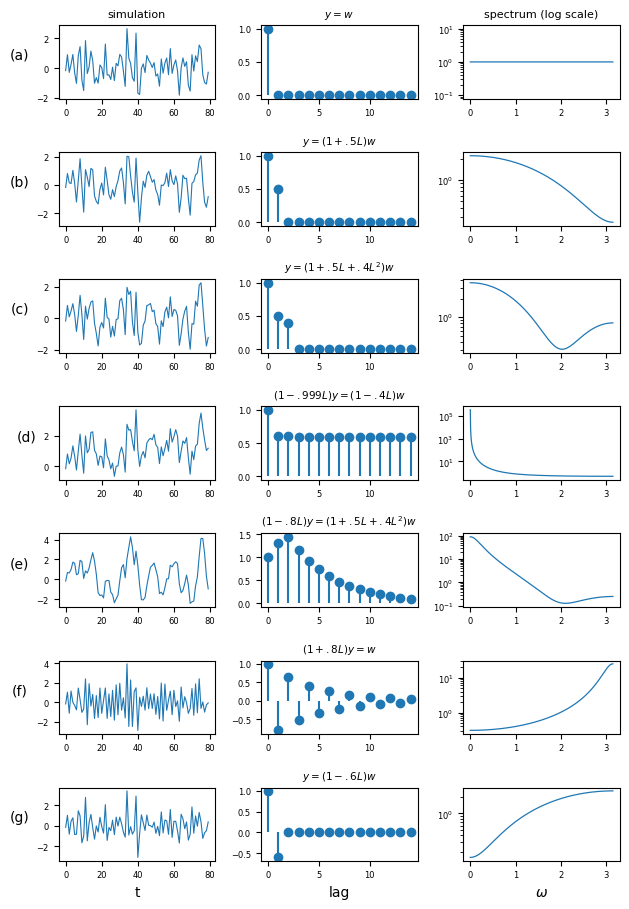

In [8]:
procs7 = {"a": ([1], [1]), "b": ([1], [1, .5]), "c": ([1], [1, .5, .4]),
          "d": ([1, -.999], [1, -.4]), "e": ([1, -.8], [1, .5, .4]),
          "f": ([1, .8], [1]), "g": ([1], [1, -.6])}
titles7 = {"a": r"$y=w$", "b": r"$y=(1+.5L)w$", "c": r"$y=(1+.5L+.4L^2)w$",
           "d": r"$(1-.999L)y=(1-.4L)w$", "e": r"$(1-.8L)y=(1+.5L+.4L^2)w$",
           "f": r"$(1+.8L)y=w$", "g": r"$y=(1-.6L)w$"}
def spec(a, b, om):
    z = np.exp(-1j * om)
    return np.abs(np.polyval(b[::-1], z))**2 / np.abs(np.polyval(a[::-1], z))**2
om = np.linspace(0, np.pi, 2001)
wsim = rng.standard_normal(80)
fig, axs = plt.subplots(7, 3, figsize=(6.4, 9.2))
for r, (k, (a, b)) in enumerate(procs7.items()):
    ysim = signal.lfilter(b, a, wsim)
    h = signal.lfilter(b, a, np.r_[1, np.zeros(99_999)])
    var_irf = h @ h
    var_spec = integrate.quad(lambda o: spec(a, b, o), 0, np.pi, limit=2000, points=[1e-4, 1e-3, 1e-2])[0] / np.pi
    assert np.isclose(var_irf, var_spec, rtol=1e-4), (k, var_irf, var_spec)
    print(f"{k}: variance {var_irf:.4f}; S(0)={spec(a, b, np.array([0.]))[0]:.4f}, S(pi)={spec(a, b, np.array([np.pi]))[0]:.4f}")
    axs[r, 0].plot(ysim, lw=.8); axs[r, 1].stem(range(15), h[:15], basefmt=" ")
    axs[r, 2].semilogy(om, spec(a, b, om), lw=.9)
    axs[r, 0].set_ylabel(f"({k})", rotation=0, labelpad=12)
    axs[r, 1].set_title(titles7[k], fontsize=7.5)
for ax, t in zip(axs[0], ["simulation", "impulse response", "spectrum (log scale)"]):
    ax.set_title(t, fontsize=8) if ax is not axs[0, 1] else None
axs[-1, 2].set_xlabel(r"$\omega$"); axs[-1, 1].set_xlabel("lag"); axs[-1, 0].set_xlabel("t")
for ax in axs.ravel(): ax.tick_params(labelsize=6)
fig.tight_layout(); save_pdf(fig, "07_bigshow"); plt.show()

## Exercise 2.8 — Cagan money demand under perfect foresight

$p_t=\frac1{1+\alpha}\sum_{j\ge0}\lambda^jm_{t+j}+c\,\lambda^{-t}$, $\lambda=\frac\alpha{1+\alpha}$. With
$(1-L)(1-\rho L)m_t=0$: $p_t=w_0m_t+w_1m_{t-1}+f_t$, $w_0=1+\frac{\alpha\rho}{1+\alpha-\alpha\rho}$,
$w_1=-\frac{\alpha\rho}{1+\alpha-\alpha\rho}$, $f_t=c\left(\frac{1+\alpha}{\alpha}\right)^t$.
Cross-check against the brute-force forward sum, and check that (1) holds on every path.

alpha=rho=1: w0, w1 = 2.0 -1.0


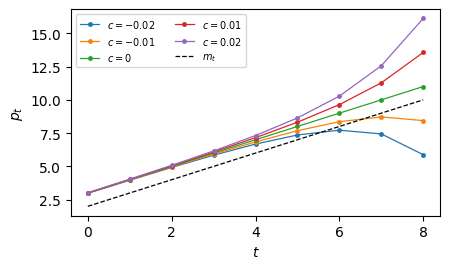

In [9]:
def m_path(m1, m2, rho, T):
    m = [m2, m1]
    for t in range(T):
        m.append((1 + rho) * m[-1] - rho * m[-2])
    return np.array(m[2:])           # m_0..m_{T-1}
def w_coef(al, rho):
    k = al * rho / (1 + al - al * rho); return 1 + k, -k
for al, rho in [(2., .6), (1., 1.), (3., .9)]:
    lam = al / (1 + al); m = m_path(1., 0., rho, 800); mlag = np.r_[1., m[:-1]]
    w0, w1 = w_coef(al, rho)
    p_formula = w0 * m[:50] + w1 * mlag[:50]
    p_brute = np.array([(1 - lam) * sum(lam**j * m[t + j] for j in range(700)) for t in range(50)])
    assert np.allclose(p_formula, p_brute, atol=1e-8), (al, rho)
al, rho = 1., 1.; w0, w1 = w_coef(al, rho); print("alpha=rho=1: w0, w1 =", w0, w1)
T8 = 9; m = m_path(1., 0., rho, T8); mlag = np.r_[1., m[:-1]]
fig, ax = plt.subplots(figsize=(4.6, 2.8))
for cc in [-0.02, -0.01, 0, 0.01, 0.02]:
    p = w0 * m + w1 * mlag + cc * ((1 + al) / al)**np.arange(T8)
    assert np.allclose((m - p)[:-1], -al * (p[1:] - p[:-1]))   # equation (1)
    ax.plot(p, marker="o", ms=2.5, lw=.9, label=f"$c={cc}$")
ax.plot(m, "k--", lw=.9, label="$m_t$")
ax.set_xlabel("$t$"); ax.set_ylabel("$p_t$"); ax.legend(ncol=2, fontsize=7)
fig.tight_layout(); save_pdf(fig, "08_cagan"); plt.show()

## Exercise 2.9 — pricing with a state-dependent stochastic discount factor

$f_t(x_t)=\frac{(MAx_t)(PAx_t)+MC_tC_t'P'}{Mx_t}$. Monte Carlo check at a random state.

In [10]:
n9, m9 = 3, 2
A9 = rng.normal(size=(n9, n9)) * .4; C9 = rng.normal(size=(n9, m9)); M9 = rng.normal(size=(1, n9)); Pp9 = rng.normal(size=(1, n9))
x9 = rng.normal(size=n9) + 2
f_formula = ((M9 @ A9 @ x9) * (Pp9 @ A9 @ x9) + M9 @ C9 @ C9.T @ Pp9.T).item() / (M9 @ x9).item()
Wd = rng.standard_normal((2_000_000, m9)); X1 = (A9 @ x9) + Wd @ C9.T
mc = np.mean((X1 @ M9.T).ravel() / (M9 @ x9).item() * (X1 @ Pp9.T).ravel())
print("formula:", f_formula, " Monte Carlo:", mc)
assert np.isclose(f_formula, mc, rtol=5e-3, atol=5e-3)

formula: -13.540663886347673  Monte Carlo: -13.534043625175137


## Exercise 2.10 — convex combinations of stationary distributions

Numerical illustration with a reducible chain that has two unit eigenvalues.

In [11]:
P10 = np.array([[.7, .3, 0, 0], [.4, .6, 0, 0], [0, 0, .5, .5], [0, 0, .2, .8]])
w, V = np.linalg.eig(P10.T); U = np.real(V[:, np.isclose(w, 1)]); U = U / U.sum(0)
for al in np.linspace(0, 1, 5):
    pb = al * U[:, 0] + (1 - al) * U[:, 1]
    assert np.allclose(P10.T @ pb, pb) and np.all(pb >= -1e-12) and np.isclose(pb.sum(), 1)
print("basis stationary distributions:\n", U.T)

basis stationary distributions:
 [[ 0.571429  0.428571  0.        0.      ]
 [-0.       -0.        0.285714  0.714286]]


## Exercise 2.11 — transient distribution of an absorbing chain

In [12]:
P11 = np.array([[1, 0, 0], [.2, .5, .3], [0, 0, 1]])
p0 = rng.dirichlet(np.ones(3)); pt = p0.copy()
for t in range(1, 40):
    pt = P11.T @ pt
    closed = np.array([p0[0] + .2 * (1 - .5**t) / .5 * p0[1], .5**t * p0[1], p0[2] + .3 * (1 - .5**t) / .5 * p0[1]])
    assert np.allclose(pt, closed)
print("formulas verified for t = 1..39, pi_0 =", p0)

formulas verified for t = 1..39, pi_0 = [0.139433 0.041691 0.818876]


## Exercise 2.12 — columns of $(P')^t$

In [13]:
P12 = rng.dirichlet(np.ones(4), size=4)
for t in (1, 3, 10):
    Pt = np.linalg.matrix_power(P12.T, t)
    for j in range(4):
        pi = np.eye(4)[j]
        for _ in range(t): pi = P12.T @ pi
        assert np.allclose(Pt[:, j], pi)
# simulation check of column 0 at t=3
xs = np.zeros(200_000, int)
cum = P12.cumsum(1)
for _ in range(3):
    u = rng.random(len(xs)); xs = (u[:, None] > cum[xs]).sum(1)
freq = np.bincount(xs, minlength=4) / len(xs)
print("simulated:", freq, " column of (P')^3:", np.linalg.matrix_power(P12.T, 3)[:, 0])
assert np.allclose(freq, np.linalg.matrix_power(P12.T, 3)[:, 0], atol=6e-3)

simulated: [0.281165 0.13587  0.293315 0.28965 ]  column of (P')^3: [0.280851 0.136054 0.293783 0.289312]


## Exercise 2.13 — LQ permanent income: Howard improvement

$x_t=[1,b_t,y_t,y_{t-1}]'$, $u_t=c_t-30$; $b_{t+1}=\beta^{-1}(30+b_t-y_t+u_t)$,
$y_{t+1}=.5+1.3y_t-.4y_{t-1}+.05w_{t+1}$. Loss $\sum\beta^t(x'Rx+u'Qu)$, $R=10^{-6}e_be_b'$, $Q=1$.
Howard (2.4.30) starting from $F_0=[0,\,1-\beta,\,0,\,0]$. Cross-check: `scipy.linalg.solve_discrete_are`.

eig(A): [0.5      0.8      1.       1.052632]  zeros of 1-1.3z+.4z^2: [1.25 2.  ]  reciprocals: [0.8 0.5]
Howard converged in 4 iterations (criterion max|F_j+1 - F_j| < 1e-10)
F* = [[26.230541  0.050019 -0.396944  0.150836]]
eig(A - BF*): [0.5     0.8     0.99998 1.     ]
theory: (1-beta) d(beta) = 0.019841269841269837  d(beta) = 0.39682539682539636
c IRF (numerical) first 5: [0.019847 0.019847 0.019847 0.019847 0.019847] 
b IRF (numerical) first 5: [ 0.       -0.03174  -0.08094  -0.132203 -0.179164] 
b IRF theory first 5: [ 0.       -0.031746 -0.080952 -0.132222 -0.17919 ]


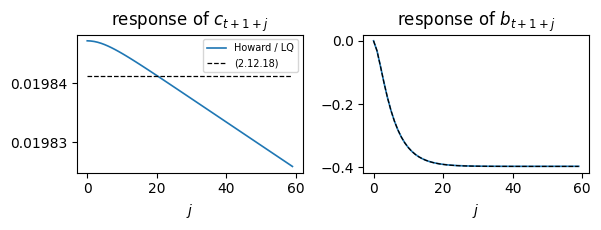

In [14]:
b13 = .95
A13 = np.array([[1, 0, 0, 0], [30 / b13, 1 / b13, -1 / b13, 0], [.5, 0, 1.3, -.4], [0, 0, 1, 0]])
B13 = np.array([[0], [1 / b13], [0], [0]]); C13 = np.array([[0], [0], [.05], [0]])
R13 = np.zeros((4, 4)); R13[1, 1] = 1e-6; Q13 = np.array([[1.]])
eigA = np.sort(np.linalg.eigvals(A13).real); zeros = np.sort(np.roots([.4, -1.3, 1]).real)
print("eig(A):", eigA, " zeros of 1-1.3z+.4z^2:", zeros, " reciprocals:", 1 / zeros)
assert np.allclose(np.sort(1 / zeros), [.5, .8])
F = np.array([[0, 1 - b13, 0, 0]])
for it in range(1, 200):
    AF = A13 - B13 @ F
    assert max(abs(np.linalg.eigvals(np.sqrt(b13) * AF))) < 1
    Pj = doublej(np.sqrt(b13) * AF.T, R13 + F.T @ Q13 @ F)
    Fn = b13 * np.linalg.solve(Q13 + b13 * B13.T @ Pj @ B13, B13.T @ Pj @ A13)
    if np.max(np.abs(Fn - F)) < 1e-10:
        F = Fn; break
    F = Fn
print(f"Howard converged in {it} iterations (criterion max|F_j+1 - F_j| < 1e-10)\nF* =", F)
Pare = la.solve_discrete_are(np.sqrt(b13) * A13, np.sqrt(b13) * B13, R13, Q13)
Fare = b13 * np.linalg.solve(Q13 + b13 * B13.T @ Pare @ B13, B13.T @ Pare @ A13)
assert np.allclose(F, Fare, rtol=1e-6, atol=1e-8)
AF = A13 - B13 @ F; print("eig(A - BF*):", np.sort(np.linalg.eigvals(AF).real))
# impulse responses of c_{t+1+j}, b_{t+1+j} to w_{t+1}
J = 60
irf_x = np.array([np.linalg.matrix_power(AF, j) @ C13 for j in range(J)])[:, :, 0]
irf_c = -(F @ irf_x.T).ravel(); irf_b = irf_x[:, 1]
A22 = np.array([[1.3, -.4], [1, 0]]); C2 = np.array([[.05], [0]]); Uy = np.array([[1, 0]])
M22 = Uy @ np.linalg.inv(np.eye(2) - b13 * A22)
dbeta = (M22 @ C2).item()
th_c = np.full(J, (1 - b13) * dbeta)
th_b = np.array([(M22 @ np.linalg.matrix_power(A22, j) @ C2).item() - dbeta for j in range(J)])
print("theory: (1-beta) d(beta) =", (1 - b13) * dbeta, " d(beta) =", dbeta)
print("c IRF (numerical) first 5:", irf_c[:5], "\nb IRF (numerical) first 5:", irf_b[:5], "\nb IRF theory first 5:", th_b[:5])
assert np.allclose(irf_c[:20], th_c[:20], rtol=2e-2) and np.allclose(irf_b[:20], th_b[:20], rtol=2e-2, atol=2e-3)
fig, axs = plt.subplots(1, 2, figsize=(6.2, 2.4))
axs[0].plot(irf_c, lw=1.2, label="Howard / LQ"); axs[0].plot(th_c, "k--", lw=.9, label="(2.12.18)")
axs[1].plot(irf_b, lw=1.2); axs[1].plot(th_b, "k--", lw=.9)
axs[0].set_title(r"response of $c_{t+1+j}$"); axs[1].set_title(r"response of $b_{t+1+j}$")
for ax in axs: ax.set_xlabel("$j$")
axs[0].legend(fontsize=7); fig.tight_layout(); save_pdf(fig, "13_irf"); plt.show()

## Exercise 2.14 — a reducible four-state chain

In [15]:
P14 = np.array([[.5, .5, 0, 0], [.1, .9, 0, 0], [0, 0, .9, .1], [0, 0, 0, 1]])
w, V = np.linalg.eig(P14.T); U14 = np.real(V[:, np.isclose(w, 1)]); U14 = U14 / U14.sum(0)
print("basis stationary distributions:\n", U14.T)
assert np.allclose(sorted(map(tuple, U14.T.round(12))), sorted([(1/6, 5/6, 0, 0), (0, 0, 0, 1)]))
yb14 = np.array([1, 2, 3, 4.])
cum = P14.cumsum(1)
for s0 in range(4):
    x_, tot = s0, 0.
    for t in range(200_000):
        tot += yb14[x_]; x_ = int((rng.random() > cum[x_]).sum())
    print(f"x0 = e{s0+1}: sample mean = {tot / 200_000:.4f}")
print("limits: 11/6 =", 11 / 6, " and 4")

basis stationary distributions:
 [[ 0.166667  0.833333 -0.       -0.      ]
 [ 0.        0.        0.        1.      ]]


x0 = e1: sample mean = 1.8341


x0 = e2: sample mean = 1.8327


x0 = e3: sample mean = 3.9999


x0 = e4: sample mean = 4.0000
limits: 11/6 = 1.8333333333333333  and 4


## Exercise 2.15 — Slutsky's filter $(1+L)^n(1-L)^m$

$S_y(\omega)=(2+2\cos\omega)^n(2-2\cos\omega)^m$, peak at $\omega^*=2\arctan\sqrt{m/n}$.

m=10, n=10: omega*=1.5708, period=4.000, log10 S(omega*)=6.02, half-power width=0.5235
m=10, n=40: omega*=0.9273, period=6.776, log10 S(omega*)=19.24, half-power width=0.3319
m=40, n=10: omega*=2.2143, period=2.838, log10 S(omega*)=19.24, half-power width=0.3319


m=120, n=30: omega*=2.2143, period=2.838, log10 S(omega*)=57.71, half-power width=0.1920


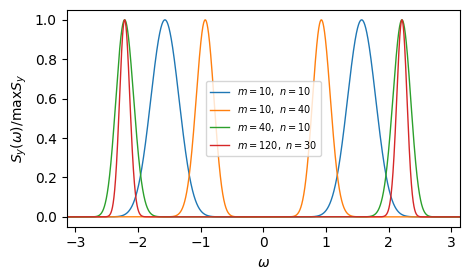

In [16]:
om = np.linspace(-np.pi, np.pi, 200_001)
fig, ax = plt.subplots(figsize=(4.8, 2.9))
for m_, n_ in [(10, 10), (10, 40), (40, 10), (120, 30)]:
    logS = n_ * np.log(2 + 2 * np.cos(om) + 1e-300) + m_ * np.log(2 - 2 * np.cos(om) + 1e-300)
    wstar = 2 * np.arctan(np.sqrt(m_ / n_))
    assert abs(abs(om[np.argmax(logS)]) - wstar) < 1e-4
    # half-power width of the peak on (0, pi)
    pos = om > 0; above = om[pos][logS[pos] > logS.max() - np.log(2)]
    print(f"m={m_}, n={n_}: omega*={wstar:.4f}, period={2*np.pi/wstar:.3f}, log10 S(omega*)={logS.max()/np.log(10):.2f}, half-power width={above.max()-above.min():.4f}")
    ax.plot(om, np.exp(logS - logS.max()), lw=1, label=f"$m={m_},\\ n={n_}$")
ax.set_xlabel(r"$\omega$"); ax.set_ylabel(r"$S_y(\omega)/\max S_y$"); ax.legend(fontsize=7)
ax.set_xlim(-np.pi, np.pi); fig.tight_layout(); save_pdf(fig, "15_slutsky"); plt.show()

## Exercise 2.16 — indicator LLN for an ergodic chain

In [17]:
P16 = np.array([[.6, .3, .1], [.2, .5, .3], [.3, .3, .4]])
w, V = np.linalg.eig(P16.T); pi16 = np.real(V[:, np.argmin(abs(w - 1))]); pi16 /= pi16.sum()
cum = P16.cumsum(1); x_ = 0; counts = np.zeros(3)
u = rng.random(300_000)
for t in range(300_000):
    counts[x_] += 1; x_ = int((u[t] > cum[x_]).sum())
print("pi =", pi16, " frequencies =", counts / counts.sum())
assert np.allclose(counts / counts.sum(), pi16, atol=5e-3)

pi = [0.375 0.375 0.25 ]  frequencies = [0.37554  0.375103 0.249357]


## Exercise 2.17 — lake model: stationary distribution, moments, MoM and ML

$P=\begin{bmatrix}1-\lambda&\lambda\\\delta&1-\delta\end{bmatrix}$ (state 1 = unemployed).

In [18]:
lam, dlt = .05, .25
P17 = np.array([[1 - lam, lam], [dlt, 1 - dlt]])
pi17 = np.array([dlt, lam]) / (lam + dlt)
assert np.allclose(P17.T @ pi17, pi17)
g = (P17 * pi17[:, None]).T        # g[i, j] = Prob(x_t = e_i, x_{t-1} = e_j) = pi_j P_ji
print("stationary:", pi17, "\ng_ij:\n", g)
def sim_lake(T, R, rng):
    x = (rng.random(R) < pi17[1]).astype(int)   # 0 = unemployed, 1 = employed
    n = np.zeros((R, 2, 2))
    for t in range(T):
        u = rng.random(R)
        xn = np.where(x == 0, (u < lam).astype(int), (u >= dlt).astype(int))
        np.add.at(n, (np.arange(R), x, xn), 1)
        x = xn
    return n                                     # n[r, i, j]: transitions i -> j
n1 = sim_lake(200_000, 1, rng)[0]
gh = n1.T / n1.sum()                            # gh[i, j] = freq(x_t = i, x_{t-1} = j)
lam_mom, dlt_mom = gh[1, 0] / (gh[0, 0] + gh[1, 0]), gh[0, 1] / (gh[0, 1] + gh[1, 1])
lam_ml, dlt_ml = n1[0, 1] / n1[0].sum(), n1[1, 0] / n1[1].sum()
print("sample g_ij:\n", gh, "\nMoM:", lam_mom, dlt_mom, " ML:", lam_ml, dlt_ml)
assert np.allclose(gh, g, atol=3e-3) and np.isclose(lam_mom, lam_ml) and np.isclose(dlt_mom, dlt_ml)
avar = np.array([lam * (1 - lam) / pi17[0], dlt * (1 - dlt) / pi17[1]])
Tm = 5000; n = sim_lake(Tm, 1000, rng)
lh = n[:, 0, 1] / n[:, 0].sum(1); dh = n[:, 1, 0] / n[:, 1].sum(1)
mc_var = np.array([lh.var() * Tm, dh.var() * Tm]); mc_cov = np.cov(lh, dh)[0, 1] * Tm
print("asymptotic T*Var (theory):", avar, " Monte Carlo:", mc_var, " T*Cov MC:", mc_cov)
assert np.allclose(mc_var, avar, rtol=.15) and abs(mc_cov) < .1 * np.sqrt(avar.prod())

stationary: [0.833333 0.166667] 
g_ij:
 [[0.791667 0.041667]
 [0.041667 0.125   ]]


sample g_ij:
 [[0.79058  0.041795]
 [0.04179  0.125835]] 
MoM: 0.05020603818013624 0.24932887907892382  ML: 0.05020603818013624 0.24932887907892382


asymptotic T*Var (theory): [0.057 1.125]  Monte Carlo: [0.059051 1.168266]  T*Cov MC: -0.019350909922662404


## Exercise 2.18 — random walk with absorbing barriers

In [19]:
P18 = np.array([[1, 0, 0, 0], [.5, 0, .5, 0], [0, .5, 0, .5], [0, 0, 0, 1]])
yb18 = np.array([1, 2, 3, 4.])
print("P ybar =", P18 @ yb18)
assert np.allclose(P18 @ yb18, yb18)
w, V = np.linalg.eig(P18); print("dimension of invariant functions:", np.isclose(w, 1).sum())
Qt, Rt = P18[1:3, 1:3], P18[1:3][:, [0, 3]]
Bm = np.linalg.solve(np.eye(2) - Qt, Rt); print("absorption probabilities (rows: from e2, e3; cols: to e1, e4):\n", Bm)
assert np.allclose(Bm, [[2/3, 1/3], [1/3, 2/3]])
cum = P18.cumsum(1); xs = np.full(100_000, 1)
for _ in range(400):
    u = rng.random(len(xs)); xs = (u[:, None] > cum[xs]).sum(1)
print("simulated from e2: share absorbed at y=1:", np.mean(xs == 0), " at y=4:", np.mean(xs == 3))
assert np.isclose(np.mean(xs == 0), 2/3, atol=.01)

P ybar = [1. 2. 3. 4.]
dimension of invariant functions: 2
absorption probabilities (rows: from e2, e3; cols: to e1, e4):
 [[0.666667 0.333333]
 [0.333333 0.666667]]


simulated from e2: share absorbed at y=1: 0.66731  at y=4: 0.33269


## Exercise 2.19 — IQ as a Kalman filter

$A=1$, $C=0$, $G=1$, $R=100$, $\hat x_0=100$, $\Sigma_0=100$. Closed forms: $\Sigma_t=100/(t+1)$,
$\mathrm{IQ}_t=\frac{100+\sum_{s<t}y_s}{t+1}$.

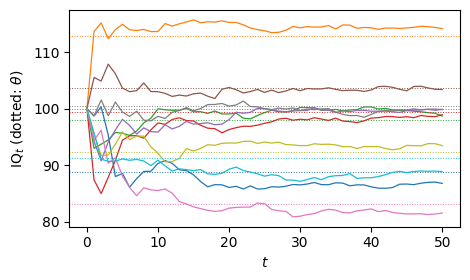

Sigma_50 = E(IQ_50 - theta)^2 = 1.9607843137254901


In [20]:
T19 = 51
fig, ax = plt.subplots(figsize=(4.8, 2.9))
for d in range(10):
    th = 100 + 10 * rng.standard_normal(); ys = th + 10 * rng.standard_normal(T19)
    iq, S = np.empty(T19), np.empty(T19); iq[0], S[0] = 100., 100.
    for t in range(T19 - 1):
        K = S[t] / (S[t] + 100); iq[t + 1] = iq[t] + K * (ys[t] - iq[t]); S[t + 1] = S[t] * 100 / (S[t] + 100)
    assert np.allclose(S, 100 / (np.arange(T19) + 1))
    assert np.allclose(iq, (100 + np.r_[0, np.cumsum(ys)[:-1]]) / (np.arange(T19) + 1))
    ln, = ax.plot(iq, lw=.9); ax.axhline(th, color=ln.get_color(), ls=":", lw=.7)
ax.set_xlabel("$t$"); ax.set_ylabel(r"$\mathrm{IQ}_t$ (dotted: $\theta$)")
fig.tight_layout(); save_pdf(fig, "19_iq"); plt.show()
print("Sigma_50 = E(IQ_50 - theta)^2 =", 100 / 51)

## Exercise 2.20 — random walk observed through two signals

$\Sigma_0=(1+\sqrt3)/2$ is the fixed point of $\Sigma'=(3\Sigma+1)/(2\Sigma+1)$; $K=\frac{\sqrt3-1}{2}[1,1]$,
$A-KG=2-\sqrt3$.

In [21]:
A20, C20, G20, R20 = np.array([[1.]]), np.array([[1.]]), np.array([[1.], [1.]]), np.eye(2)
K20, S20 = kalman_steady(A20, C20, G20, R20)
print("Sigma =", S20.item(), " K =", K20, " A-KG =", (A20 - K20 @ G20).item())
assert np.isclose(S20.item(), 1.36602540378444) and np.isclose(S20.item(), (1 + np.sqrt(3)) / 2)
assert np.allclose(K20, (np.sqrt(3) - 1) / 2) and np.isclose((A20 - K20 @ G20).item(), 2 - np.sqrt(3))
# one step of (2.7.14d) from Sigma_0 leaves it unchanged
S0 = np.array([[1.36602540378444]]); K0 = A20 @ S0 @ G20.T @ np.linalg.inv(G20 @ S0 @ G20.T + R20)
assert np.isclose((C20 @ C20.T + K0 @ R20 @ K0.T + (A20 - K0 @ G20) @ S0 @ (A20 - K0 @ G20).T).item(), S0.item())
# simulation: innovations are white with covariance G Sigma G' + R
T = 200_000; x = rng.normal(0, np.sqrt(S0.item())); xh = 0.; a_ = np.empty((T, 2))
for t in range(T):
    yv = G20[:, 0] * x + rng.standard_normal(2); a_[t] = yv - G20[:, 0] * xh
    xh = xh + (K20 @ a_[t]).item(); x = x + rng.standard_normal()
Om = G20 @ S20 @ G20.T + R20
print("sample E aa':\n", a_.T @ a_ / T, "\ntheory:\n", Om, "\nlag-1 autocov:\n", a_[1:].T @ a_[:-1] / T)
assert np.allclose(a_.T @ a_ / T, Om, atol=.05) and np.allclose(a_[1:].T @ a_[:-1] / T, 0, atol=.03)

Sigma = 1.366025403784438  K = [[0.366025 0.366025]]  A-KG = 0.26794919243112403


sample E aa':
 [[2.367754 1.361371]
 [1.361371 2.354889]] 
theory:
 [[2.366025 1.366025]
 [1.366025 2.366025]] 
lag-1 autocov:
 [[-0.0025   -0.00375 ]
 [-0.009039 -0.007869]]


## Exercise 2.21 — impulse response of the innovations representation / VAR

$y_{t+j}$ responds to $a_t$ by $I$ at $j=0$ and $GA^{j-1}K$ for $j\ge1$. Cross-check: invert the VAR
$\Phi_j=G(A-KG)^{j-1}K$ by $\Psi_j=\sum_{k=1}^j\Phi_k\Psi_{j-k}$.

In [22]:
def irf_state(A, K, G, J):
    return [np.eye(G.shape[0])] + [G @ np.linalg.matrix_power(A, j - 1) @ K for j in range(1, J)]
def irf_var(A, K, G, J):
    Phi = [None] + [G @ np.linalg.matrix_power(A - K @ G, j - 1) @ K for j in range(1, J)]
    Psi = [np.eye(G.shape[0])]
    for j in range(1, J):
        Psi.append(sum(Phi[k] @ Psi[j - k] for k in range(1, j + 1)))
    return Psi
for (A_, K_, G_) in [(A20, K20, G20)]:
    for P_, Q_ in zip(irf_state(A_, K_, G_, 15), irf_var(A_, K_, G_, 15)):
        assert np.allclose(P_, Q_)
print("2.20 system: Psi_1 =\n", irf_state(A20, K20, G20, 3)[1])

2.20 system: Psi_1 =
 [[0.366025 0.366025]
 [0.366025 0.366025]]


## Exercise 2.22 — Kalman filter with cross-products

Recursion $K_t=(CD'+A\Sigma_tG')(DD'+G\Sigma_tG')^{-1}$,
$\Sigma_{t+1}=(A-K_tG)\Sigma_t(A-K_tG)'+(C-K_tD)(C-K_tD)'$, checked against brute-force Gaussian
conditioning of $x_T$ on $(y_1,\dots,y_T)$.

In [23]:
n, m, T = 2, 2, 6
A22_ = np.array([[.8, .2], [-.1, .6]]); C22 = rng.normal(size=(n, m)); D22 = rng.normal(size=(m, m))
G22 = rng.normal(size=(m, n)); xh0 = rng.normal(size=n); S0 = np.eye(n) * 1.5
print("CD' =", C22 @ D22.T, "(nonzero: correlated state and measurement noise)")
# recursion
xh, S = xh0.copy(), S0.copy()
# brute force: z = [x0 - xh0; w1..wT], Var(z) = blkdiag(S0, I)
dim = n + m * T; Vz = la.block_diag(S0, np.eye(m * T))
Lx = np.zeros((n, dim)); Lx[:, :n] = np.eye(n)   # x_t - A^t xh0 as a linear map of z
Ly, ymean = [], []
xmean = xh0.copy()
x_true = xh0 + la.cholesky(S0, lower=True) @ rng.standard_normal(n); zdraw = np.r_[x_true - xh0, rng.standard_normal(m * T)]
ys = []
for t in range(1, T + 1):
    Wsel = np.zeros((m, dim)); Wsel[:, n + m * (t - 1): n + m * t] = np.eye(m)
    Ly.append(G22 @ Lx + D22 @ Wsel); ymean.append(G22 @ xmean)
    ys.append(ymean[-1] + Ly[-1] @ zdraw)
    Lx = A22_ @ Lx + C22 @ Wsel; xmean = A22_ @ xmean
    # recursion step using y_t
    a = ys[-1] - G22 @ xh
    K = (C22 @ D22.T + A22_ @ S @ G22.T) @ np.linalg.inv(D22 @ D22.T + G22 @ S @ G22.T)
    xh = A22_ @ xh + K @ a
    S = (A22_ - K @ G22) @ S @ (A22_ - K @ G22).T + (C22 - K @ D22) @ (C22 - K @ D22).T
Ly = np.vstack(Ly); ymean = np.concatenate(ymean); ys = np.concatenate(ys)
Sxy = Lx @ Vz @ Ly.T; Syy = Ly @ Vz @ Ly.T
S_brute = Lx @ Vz @ Lx.T - Sxy @ np.linalg.solve(Syy, Sxy.T)
xh_brute = xmean + Sxy @ np.linalg.solve(Syy, ys - ymean)
print("Sigma_T recursion:\n", S, "\nSigma_T brute force:\n", S_brute)
assert np.allclose(S, S_brute) and np.allclose(xh, xh_brute)

CD' = [[2.199608 0.925928]
 [0.723598 0.523206]] (nonzero: correlated state and measurement noise)
Sigma_T recursion:
 [[0.045488 0.04222 ]
 [0.04222  0.039205]] 
Sigma_T brute force:
 [[0.045488 0.04222 ]
 [0.04222  0.039205]]


## Exercise 2.23 — monopolist learning the demand intercept

Signal $s_t=p_t+bQ_t=a+\sigma_p\epsilon_t$; $m_t=E[a\mid p^t,Q^t]$, $Q_t=m_{t-1}/(2b)$,
$1/\Sigma_{t}=1/\sigma_a^2+t/\sigma_p^2$. $E_{t-1}p_t=m_{t-1}/2\to a/2$.

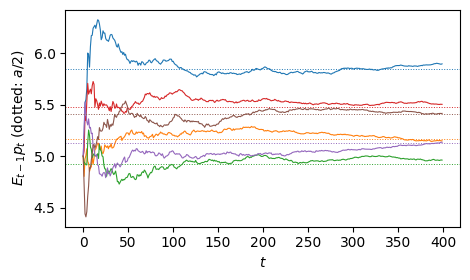

In [24]:
mua, sa, sp, b = 10., 1., 2., 1.
T23 = 400; fig, ax = plt.subplots(figsize=(4.8, 2.9))
for d in range(6):
    a = mua + sa * rng.standard_normal(); mm, S = mua, sa**2
    Ep = np.empty(T23); mpath = np.empty(T23); ssum = 0.
    for t in range(T23):
        Q = mm / (2 * b); Ep[t] = mm - b * Q
        p = a - b * Q + sp * rng.standard_normal()
        K = S / (S + sp**2); mm = mm + K * (p + b * Q - mm); S = S * sp**2 / (S + sp**2)
        ssum += p + b * Q
        mpath[t] = mm
        assert np.isclose(1 / S, 1 / sa**2 + (t + 1) / sp**2)
        assert np.isclose(mm, (mua / sa**2 + ssum / sp**2) / (1 / sa**2 + (t + 1) / sp**2))
    ln, = ax.plot(Ep, lw=.8); ax.axhline(a / 2, color=ln.get_color(), ls=":", lw=.7)
    assert abs(mpath[-1] - a) < 5 * np.sqrt(S)
ax.set_xlabel("$t$"); ax.set_ylabel(r"$E_{t-1}p_t$ (dotted: $a/2$)")
fig.tight_layout(); save_pdf(fig, "23_monopolist"); plt.show()

## Exercise 2.24 — steady-state predictive distribution of $y_t$

$z_{t+1}=.9z_t+w_{t+1}$, $y_t=z_t+v_t$. Riccati: $\Sigma^2-.81\Sigma-1=0$. Cross-check with the
Kolmogorov–Szegő formula $\Omega=\exp\{\frac1{2\pi}\int\log S_y\}$, $S_y=|1-.9e^{-i\omega}|^{-2}+1$.

In [25]:
K24, S24 = kalman_steady(np.array([[.9]]), np.array([[1.]]), np.array([[1.]]), np.array([[1.]]))
Sig = (.81 + np.sqrt(.81**2 + 4)) / 2; Om24 = Sig + 1
assert np.isclose(S24.item(), Sig)
Sy = lambda o: 1 / np.abs(1 - .9 * np.exp(-1j * o))**2 + 1
kolm = np.exp(integrate.quad(lambda o: np.log(Sy(o)), -np.pi, np.pi)[0] / (2 * np.pi))
print(f"Sigma={Sig:.6f}, K={K24.item():.6f}, A-KG={.9-K24.item():.6f}, Omega={Om24:.6f}, Kolmogorov={kolm:.6f}")
print("stationary z: z0_hat = 0, Sigma0 =", 1 / (1 - .81))
assert np.isclose(kolm, Om24)

Sigma=1.483900, K=0.537667, A-KG=0.362333, Omega=2.483900, Kolmogorov=2.483900
stationary z: z0_hat = 0, Sigma0 = 5.263157894736843


## Exercise 2.25 — the two classic permanent-income examples

Example 2 uses the Muth gain: $\Sigma^2=Q(\Sigma+R)$ with $Q=\sigma_1^2$, $R=\sigma_2^2$, $K=\Sigma/(\Sigma+R)$.
Check (2.12.18) numerically and the MA(1) autocovariances of $\Delta y$.

In [26]:
b25 = .95
def ex1(s1, s2):
    A22 = np.diag([1., 0.]); C2 = np.diag([s1, s2]); Uy = np.array([[1., 1.]])
    M = Uy @ np.linalg.inv(np.eye(2) - b25 * A22)
    return (1 - b25) * M @ C2, M @ (A22 - np.eye(2))
def ex2(s1, s2):
    Sg = (s1**2 + np.sqrt(s1**4 + 4 * s1**2 * s2**2)) / 2; K = Sg / (Sg + s2**2)
    Kk, Sk = kalman_steady(np.array([[1.]]), np.array([[s1]]), np.array([[1.]]), np.array([[s2**2]]))
    assert np.isclose(Kk.item(), K) and np.isclose(Sk.item(), Sg)
    A22 = np.array([[1, -(1 - K)], [0, 0]]); C2 = np.array([[1.], [1.]]); Uy = np.array([[1., 0.]])
    M = Uy @ np.linalg.inv(np.eye(2) - b25 * A22)
    dc, db = ((1 - b25) * M @ C2).item(), M @ (A22 - np.eye(2))
    assert np.isclose(dc, 1 - b25 * (1 - K)) and np.allclose(db, [[0, K - 1]])
    Om = Sg + s2**2   # innovation variance of y
    assert np.isclose(Om * (1 + (1 - K)**2), s1**2 + 2 * s2**2) and np.isclose(-(1 - K) * Om, -s2**2)
    return K, Sg, Om, dc, db
for s1, s2 in [(1, 1), (2, 1)]:
    c1, d1 = ex1(s1, s2); K, Sg, Om, dc, db = ex2(s1, s2)
    print(f"sigma1={s1}, sigma2={s2}: Ex.1 dc coefs {c1.ravel()}, db coefs on z {d1.ravel()} | "
          f"Ex.2 Sigma={Sg:.5f}, K={K:.5f}, var(a)={Om:.5f}, dc=[{dc:.5f}]a, db=[{db[0,1]:.5f}]a")

sigma1=1, sigma2=1: Ex.1 dc coefs [1.   0.05], db coefs on z [ 0. -1.] | Ex.2 Sigma=1.61803, K=0.61803, var(a)=2.61803, dc=[0.63713]a, db=[-0.38197]a
sigma1=2, sigma2=1: Ex.1 dc coefs [2.   0.05], db coefs on z [ 0. -1.] | Ex.2 Sigma=4.82843, K=0.82843, var(a)=5.82843, dc=[0.83701]a, db=[-0.17157]a


## Exercise 2.26 — math and verbal IQ

$\Sigma_{t+1}^{-1}=\Sigma_t^{-1}+G_t'G_t/50$; recursion checked against the precision form.

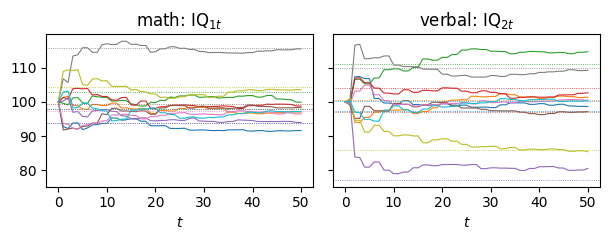

Sigma_50 =
 [[ 2.438371 -0.241158]
 [-0.241158  2.003853]]
two-period precision increment:
 [[0.016202 0.001998]
 [0.001998 0.019802]]  eigenvalues: [0.015313 0.020691]
Sigma_5000 =
 [[ 0.024993 -0.002521]
 [-0.002521  0.02045 ]]


In [27]:
Gs = [np.array([[.9, .1]]), np.array([[.01, .99]])]
T26 = 51; fig, axs = plt.subplots(1, 2, figsize=(6.2, 2.5), sharey=True)
for d in range(10):
    th = 100 + 10 * rng.standard_normal(2); iq = np.array([100., 100.]); S = 100 * np.eye(2)
    path = [iq.copy()]
    for t in range(T26 - 1):
        Gt = Gs[t % 2]; yt = (Gt @ th).item() + np.sqrt(50) * rng.standard_normal()
        K = S @ Gt.T / ((Gt @ S @ Gt.T).item() + 50)
        iq = iq + (K * (yt - (Gt @ iq).item())).ravel(); S = S - K @ Gt @ S
        path.append(iq.copy())
    path = np.array(path)
    prec = np.eye(2) / 100 + sum(Gs[s % 2].T @ Gs[s % 2] for s in range(T26 - 1)) / 50
    assert np.allclose(S, np.linalg.inv(prec))
    for k in range(2):
        ln, = axs[k].plot(path[:, k], lw=.8); axs[k].axhline(th[k], color=ln.get_color(), ls=":", lw=.6)
axs[0].set_title(r"math: $\mathrm{IQ}_{1t}$"); axs[1].set_title(r"verbal: $\mathrm{IQ}_{2t}$")
for ax in axs: ax.set_xlabel("$t$")
fig.tight_layout(); save_pdf(fig, "26_iq2"); plt.show()
print("Sigma_50 =\n", S)
M2 = (Gs[0].T @ Gs[0] + Gs[1].T @ Gs[1]) / 50
print("two-period precision increment:\n", M2, " eigenvalues:", np.linalg.eigvalsh(M2))
assert np.all(np.linalg.eigvalsh(M2) > 0)
S5000 = np.linalg.inv(np.eye(2) / 100 + 2500 * M2); print("Sigma_5000 =\n", S5000)

## Exercise 2.27 — two permanent-income consumers

$c^i_t=(1-\beta)(y^i_t-b^i_t)+.75\beta$, $b^i_{t+1}=b^i_t-y^i_t+.75$. Checks: debt laws, $b^1+b^2=0$,
$c^1+c^2=1.5$, $E_tm^i_{t+1}=\beta$, and the sign of the SDF deviations.

In [28]:
b27, gam = .95, 3.; T = 300; s = rng.integers(0, 2, T)
y1, y2 = 1 - .5 * s, .5 + .5 * s
b1, b2 = np.zeros(T + 1), np.zeros(T + 1); c1, c2 = np.empty(T), np.empty(T)
for t in range(T):
    c1[t] = (1 - b27) * (y1[t] - b1[t]) + .75 * b27; c2[t] = (1 - b27) * (y2[t] - b2[t]) + .75 * b27
    b1[t + 1] = (c1[t] + b1[t] - y1[t]) / b27; b2[t + 1] = (c2[t] + b2[t] - y2[t]) / b27
assert np.allclose(np.diff(b1), np.where(s == 0, -.25, .25)) and np.allclose(np.diff(b2), np.where(s == 0, .25, -.25))
assert np.allclose(b1 + b2, 0) and np.allclose(c1 + c2, 1.5)
assert np.allclose((1 - b27) * b1[:-1] + c1, (1 - b27) * y1 + .75 * b27)   # cointegrating residual
# SDF of consumer 1 at date t for both values of s_{t+1}
t = 10
c1_next = {sn: (1 - b27) * ((1 - .5 * sn) - b1[t + 1]) + .75 * b27 for sn in (0, 1)}
m1 = {sn: b27 * (gam - c1_next[sn]) / (gam - c1[t]) for sn in (0, 1)}
dev = .25 * b27 * (1 - b27) / (gam - c1[t])
print("m1(s'=0), m1(s'=1):", m1, "  beta -/+ dev:", b27 - dev, b27 + dev)
assert np.isclose(m1[0], b27 - dev) and np.isclose(m1[1], b27 + dev)       # signs opposite to the printed statement
assert np.isclose(.5 * (m1[0] + m1[1]), b27)

m1(s'=0), m1(s'=1): {0: np.float64(0.9447513812154694), 1: np.float64(0.9552486187845303)}   beta -/+ dev: 0.9447513812154695 0.9552486187845304


## Exercise 2.28 — a non-invertible MA(1)

$y_t=\epsilon_t-2\epsilon_{t-1}$: $x_t=[\epsilon_t,\epsilon_{t-1}]'$, $A=\begin{bmatrix}0&0\\1&0\end{bmatrix}$,
$C=[1,0]'$, $G=[1,-2]$, $R=0$. Kalman: innovations $y_t=a_t-.5a_{t-1}$, $Ea_t^2=4$.

In [29]:
A28 = np.array([[0., 0], [1, 0]]); C28 = np.array([[1.], [0]]); G28 = np.array([[1., -2]])
K28, S28 = kalman_steady(A28, C28, G28, np.zeros((1, 1)), S0=np.eye(2))
Om28 = (G28 @ S28 @ G28.T).item()
ma = [(G28 @ np.linalg.matrix_power(A28, j - 1) @ K28).item() for j in (1, 2, 3)]
print("K =", K28.ravel(), " Sigma =\n", S28, "\nvar(a) =", Om28, " MA coefs of innovations rep:", ma)
assert np.isclose(Om28, 4) and np.allclose(ma, [-.5, 0, 0])
AR = [(G28 @ np.linalg.matrix_power(A28 - K28 @ G28, j - 1) @ K28).item() for j in range(1, 8)]
print("A_j (y_t = sum A_j y_{t-j} + a_t):", np.round(AR, 6))
assert np.allclose(AR, [-.5**j for j in range(1, 8)])
T = 200_000; eps = rng.standard_normal(T + 1); ysim = eps[1:] - 2 * eps[:-1]; e = eps[1:]
Xl = np.column_stack([ysim[20 - j: T - j] for j in range(1, 21)])
coef = np.linalg.lstsq(Xl, ysim[20:], rcond=None)[0]; resid = ysim[20:] - Xl @ coef
print("OLS AR coefs (first 5):", coef[:5], " residual variance:", resid.var())
assert np.allclose(coef[:5], [-.5**j for j in range(1, 6)], atol=.01) and np.isclose(resid.var(), 4, rtol=.02)
# part f: eps_t = -sum_{j>=1} .5^j y_{t+j}
fwd = np.array([-sum(.5**j * ysim[t + j] for j in range(1, 60)) for t in range(1000)])
assert np.allclose(fwd, e[:1000], atol=1e-12)
print("part (f) reconstruction error:", np.max(np.abs(fwd - e[:1000])))

K = [0.   0.25]  Sigma =
 [[1.   0.  ]
 [0.   0.75]] 
var(a) = 4.000000000000043  MA coefs of innovations rep: [-0.4999999999999787, 0.0, 0.0]
A_j (y_t = sum A_j y_{t-j} + a_t): [-0.5      -0.25     -0.125    -0.0625   -0.03125  -0.015625 -0.007812]


OLS AR coefs (first 5): [-0.49771  -0.246012 -0.123143 -0.059979 -0.03078 ]  residual variance: 4.022410626843206
part (f) reconstruction error: 2.220446049250313e-15


## Exercise 2.29 — pure prediction, Lyapunov equations, and a Howard-style Kalman filter

$\mu_t=\sum_j A'^jRx_{t+j}=Px_t$, $P=R+A'PA$. Policy evaluation for a fixed gain $K$:
$\Sigma_K=(A-KG)\Sigma_K(A-KG)'+CC'+KRK'$; improvement $K\leftarrow A\Sigma_KG'(G\Sigma_KG'+R)^{-1}$.

In [30]:
n = 3; A29 = rng.normal(size=(n, n)); A29 *= .8 / max(abs(np.linalg.eigvals(A29)))
L = rng.normal(size=(n, n)); R29 = L @ L.T + np.eye(n)
P29 = la.solve_discrete_lyapunov(A29.T, R29)
assert np.allclose(P29, sum(np.linalg.matrix_power(A29.T, j) @ R29 @ np.linalg.matrix_power(A29, j) for j in range(400)))
x0 = rng.normal(size=n); xs = [np.linalg.matrix_power(A29, j) @ x0 for j in range(400)]
mu_right = sum(np.linalg.matrix_power(A29.T, j) @ R29 @ xs[j] for j in range(400))
mu_print = R29 @ sum(np.linalg.matrix_power(A29.T, j) @ xs[j] for j in range(400))
mu1 = sum(np.linalg.matrix_power(A29.T, j) @ R29 @ xs[j + 1] for j in range(399))
print("residual of (1) with A'^j R ordering:", np.max(np.abs(mu_right - (R29 @ x0 + A29.T @ mu1))))
print("residual of (1) with printed R A'^j ordering:",
      np.max(np.abs(mu_print - (R29 @ x0 + A29.T @ (R29 @ sum(np.linalg.matrix_power(A29.T, j) @ xs[j + 1] for j in range(399)))))))
assert np.allclose(mu_right, P29 @ x0)
def howard_kalman(A, C, G, R, K0, tol=1e-12):
    K = K0
    for it in range(1, 500):
        AK = A - K @ G
        SK = la.solve_discrete_lyapunov(AK, C @ C.T + K @ R @ K.T)
        Kn = A @ SK @ G.T @ np.linalg.inv(G @ SK @ G.T + R)
        if np.max(np.abs(Kn - K)) < tol: return Kn, SK, it
        K = Kn
    raise RuntimeError
for (A_, C_, G_, R_) in [(np.array([[.9]]), np.array([[1.]]), np.array([[1.]]), np.array([[1.]])),
                         (np.array([[.95, .3], [0, .5]]), np.eye(2), np.array([[1., 0], [1, 1]]), np.eye(2))]:
    Kh, Sh, it = howard_kalman(A_, C_, G_, R_, np.zeros((A_.shape[0], G_.shape[0])))
    Kr, Sr = kalman_steady(A_, C_, G_, R_)
    assert np.allclose(Kh, Kr) and np.allclose(Sh, Sr)
    print(f"Howard-Kalman converged in {it} iterations; K =", Kh.ravel())

residual of (1) with A'^j R ordering:

 4.263256414560601e-14
residual of (1) with printed R A'^j ordering: 9.422982012826278
Howard-Kalman converged in 6 iterations; K = [0.537667]
Howard-Kalman converged in 6 iterations; K = [ 0.357239  0.324363 -0.123631  0.213072]


## Exercise 2.30 — Phelps–Pollak meets Howard: Markov perfect equilibrium in an LQ problem

Example: $A=\begin{bmatrix}1.02&.1\\0&.9\end{bmatrix}$, $B=[1,.5]'$, $R=I$, $Q=1$, $\beta=.95$.
MPE iteration: $P_F=R+F'QF+\beta(A-BF)'P_F(A-BF)$, $F\leftarrow\delta\beta(Q+\delta\beta B'P_FB)^{-1}B'P_FA$.

In [31]:
A30 = np.array([[1.02, .1], [0, .9]]); B30 = np.array([[1.], [.5]]); R30 = np.eye(2); Q30 = np.array([[1.]]); b30 = .95
def P_of_F(F):
    AF = A30 - B30 @ F
    return la.solve_discrete_lyapunov(np.sqrt(b30) * AF.T, R30 + F.T @ Q30 @ F)
def best_resp(P, dl):
    return dl * b30 * np.linalg.solve(Q30 + dl * b30 * B30.T @ P @ B30, B30.T @ P @ A30)
Pstar = la.solve_discrete_are(np.sqrt(b30) * A30, np.sqrt(b30) * B30, R30, Q30)
Fstar = best_resp(Pstar, 1.)
def mpe(dl, F0, tol=1e-12):
    F = F0
    for it in range(1, 1000):
        Fn = best_resp(P_of_F(F), dl)
        if np.max(np.abs(Fn - F)) < tol: return Fn, it
        F = Fn
    raise RuntimeError
for dl in (1., .8, .6):
    Fm, it = mpe(dl, Fstar)
    assert np.allclose(best_resp(P_of_F(Fm), dl), Fm)
    F0dict = best_resp(Pstar, dl)
    print(f"delta={dl}: MPE F={Fm.ravel()} ({it} it.) | dictator u0 rule={F0dict.ravel()} | F*(t>=1)={Fstar.ravel()}")
    if dl == 1.:
        assert np.allclose(Fm, Fstar) and np.allclose(F0dict, Fstar)
    else:
        assert not np.allclose(Fm, Fstar) and not np.allclose(F0dict, Fstar)

delta=1.0: MPE F=[0.580578 0.209347] (1 it.) | dictator u0 rule=[0.580578 0.209347] | F*(t>=1)=[0.580578 0.209347]
delta=0.8: MPE F=[0.535287 0.193215] (10 it.) | dictator u0 rule=[0.534341 0.192674] | F*(t>=1)=[0.580578 0.209347]
delta=0.6: MPE F=[0.477215 0.173063] (14 it.) | dictator u0 rule=[0.471727 0.170097] | F*(t>=1)=[0.580578 0.209347]
